# House Price Prediction using Linear Regression

## Objective

The objective of this project is to build a Linear Regression model to predict house prices using property characteristics.

The project focuses on understanding the complete regression workflow, including exploratory data analysis, feature selection, model training, evaluation, coefficient interpretation, and analysis of relationships between predictors.


## 1. Importing Required Libraries

The following libraries are used for data manipulation, visualization, and machine learning.

* **Pandas** is used to load and manipulate the dataset.
* **NumPy** provides numerical operations.
* **Matplotlib** is used for data visualization.
* **Scikit-learn** provides the train-test split, Linear Regression model, and evaluation metrics.


## 2. Loading the Dataset

The housing dataset is loaded into a Pandas DataFrame so that its structure, features, and target variable can be explored before building the model.


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


df = pd.read_csv('Housing.csv')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


## 3. Understanding the Dataset

Before building a machine learning model, it is important to understand the structure and quality of the data.

The following checks are performed:

* Number of rows and columns
* Data types of the features
* Missing values
* Duplicate records
* Basic statistical information

This helps identify potential data-quality issues before modeling.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
print(df.shape)
print(df.describe())
print(df.columns)

(21613, 21)
                 id         price      bedrooms     bathrooms   sqft_living  \
count  2.161300e+04  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean   4.580306e+09  5.400886e+05      3.370795      2.114757   2079.899736   
std    2.876570e+09  3.671268e+05      0.930105      0.770163    918.440897   
min    1.000102e+06  7.500000e+04      0.000000      0.000000    290.000000   
25%    2.123049e+09  3.219500e+05      3.000000      1.750000   1427.000000   
50%    3.904930e+09  4.500000e+05      3.000000      2.250000   1910.000000   
75%    7.308900e+09  6.450000e+05      4.000000      2.500000   2550.000000   
max    9.900000e+09  7.700000e+06     33.000000      8.000000  13540.000000   

           sqft_lot        floors    waterfront          view     condition  \
count  2.161300e+04  21613.000000  21613.000000  21613.000000  21613.000000   
mean   1.510697e+04      1.494309      0.007542      0.234303      3.409430   
std    4.142051e+04      0.539989      

In [5]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [6]:
#no null values

In [7]:
df.duplicated().sum()

0

no duplicate values

In [8]:
df['date'].head(10)

0    20141013T000000
1    20141209T000000
2    20150225T000000
3    20141209T000000
4    20150218T000000
5    20140512T000000
6    20140627T000000
7    20150115T000000
8    20150415T000000
9    20150312T000000
Name: date, dtype: object

In [9]:
df['date'].tail(10)

21603    20140825T000000
21604    20150126T000000
21605    20141014T000000
21606    20150326T000000
21607    20150219T000000
21608    20140521T000000
21609    20150223T000000
21610    20140623T000000
21611    20150116T000000
21612    20141015T000000
Name: date, dtype: object

In [10]:
df['date'].nunique()

372

In [11]:
df.describe(include='all')

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
unique,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,20140623T000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.580306e+09,NaN,5.400886e+05,3.370795,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876570e+09,NaN,3.671268e+05,0.930105,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,NaN,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,NaN,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,NaN,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,NaN,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000


In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
df['date'].dtype

dtype('<M8[ns]')

In [14]:
df[['date']].head()

,date
0,2014-10-13
1,2014-12-09
2,2015-02-25
3,2014-12-09
4,2015-02-18


In [15]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [16]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,21613.0,4580306147.70999,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0,2876569751.888593
date,21613,2014-10-29 04:38:01.959931648,2014-05-02 00:00:00,2014-07-22 00:00:00,2014-10-16 00:00:00,2015-02-17 00:00:00,2015-05-27 00:00:00,NaN
price,21613.0,540088.57669,75000.0,321950.0,450000.0,645000.0,7700000.0,367126.825086
bedrooms,21613.0,3.370795,0.0,3.0,3.0,4.0,33.0,0.930105
bathrooms,21613.0,2.114757,0.0,1.75,2.25,2.5,8.0,0.770163
sqft_living,21613.0,2079.899736,290.0,1427.0,1910.0,2550.0,13540.0,918.440897
sqft_lot,21613.0,15106.967566,520.0,5040.0,7618.0,10688.0,1651359.0,41420.511515
floors,21613.0,1.494309,1.0,1.0,1.5,2.0,3.5,0.539989
waterfront,21613.0,0.007542,0.0,0.0,0.0,0.0,1.0,0.086517
view,21613.0,0.234303,0.0,0.0,0.0,0.0,4.0,0.766318


In [19]:
df[['id','date','zipcode']].head()

,id,date,zipcode
0,7229300521,2014-10-13,98178
1,6414100192,2014-12-09,98125
2,5631500400,2015-02-25,98028
3,2487200875,2014-12-09,98136
4,1954400510,2015-02-18,98074


In [20]:
df['zipcode'].nunique()

70

In [21]:
df['id'].nunique()

21436

no of unique ids != no of rows

few unique value of zipcode 


In [22]:
id_counts = df['id'].value_counts()
id_counts[id_counts>1]

id
795000620     3
8651510380    2
2568300045    2
9353300600    2
4139480200    2
             ..
3630120700    2
4031000520    2
4302201085    2
2206700215    2
6021501535    2
Name: count, Length: 176, dtype: int64

In [23]:
duplicate_id = id_counts[id_counts > 1].index[0]
df[df['id'] == duplicate_id]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
17602,795000620,2014-09-24,115000.0,3,1.0,1080,6250,1.0,0,0,...,5,1080,0,1950,0,98168,47.5045,-122.33,1070,6250
17603,795000620,2014-12-15,124000.0,3,1.0,1080,6250,1.0,0,0,...,5,1080,0,1950,0,98168,47.5045,-122.33,1070,6250
17604,795000620,2015-03-11,157000.0,3,1.0,1080,6250,1.0,0,0,...,5,1080,0,1950,0,98168,47.5045,-122.33,1070,6250


property with id 795000620, is the same property appearing 3 times in the sales record with different date and price

In [24]:
#since id is a unique identifier no need of it 
df = df.drop('id',axis=1)

price is our target variable therefore checking info on it

In [32]:
print('Min price: ',df['price'].min())
print('Max price: ', df['price'].max())
print('Mean price: ',df['price'].mean())
print('Median price: ',df['price'].median())

Min price:  75000.0
Max price:  7700000.0
Mean price:  540088.5766899551
Median price:  450000.0


mean > median
therefore the price might be skewed

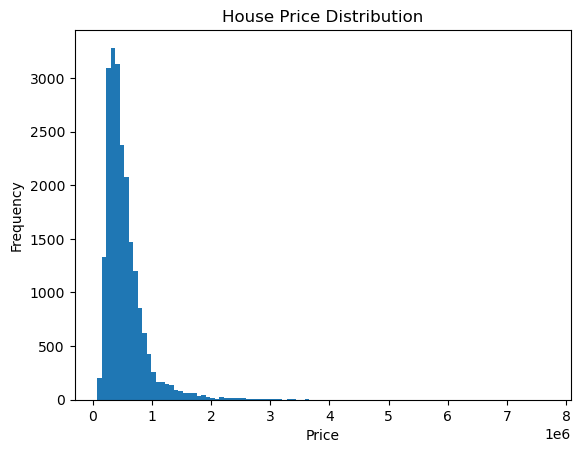

In [34]:
import matplotlib.pyplot as plt

plt.hist(df['price'], bins =100)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('House Price Distribution')
plt.show()

In [35]:
df['price'].skew()

4.024080394890599

shows heavily right skewed

heavily right skewed target can make linear regression harder to fit because very expensive houses can have a larger influence on the error objective

since minimizes MSE, for expensive house if predicts far away then error becomes huge

In [38]:
#investigating other features

major physical properties

bedrooms, bathrooms, sqft_living, sqft_lot,floors, waterfront, view, condition, grade

In [39]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

## 4. Distribution of Numerical Features

The distributions of numerical features are examined to understand their ranges and identify skewed variables.

A highly skewed feature can contain a small number of extremely large or small observations that influence the scale of a visualization or model.

For example, `sqft_lot` has a highly skewed distribution, with most observations concentrated at smaller lot sizes and a relatively small number of houses having very large lots.


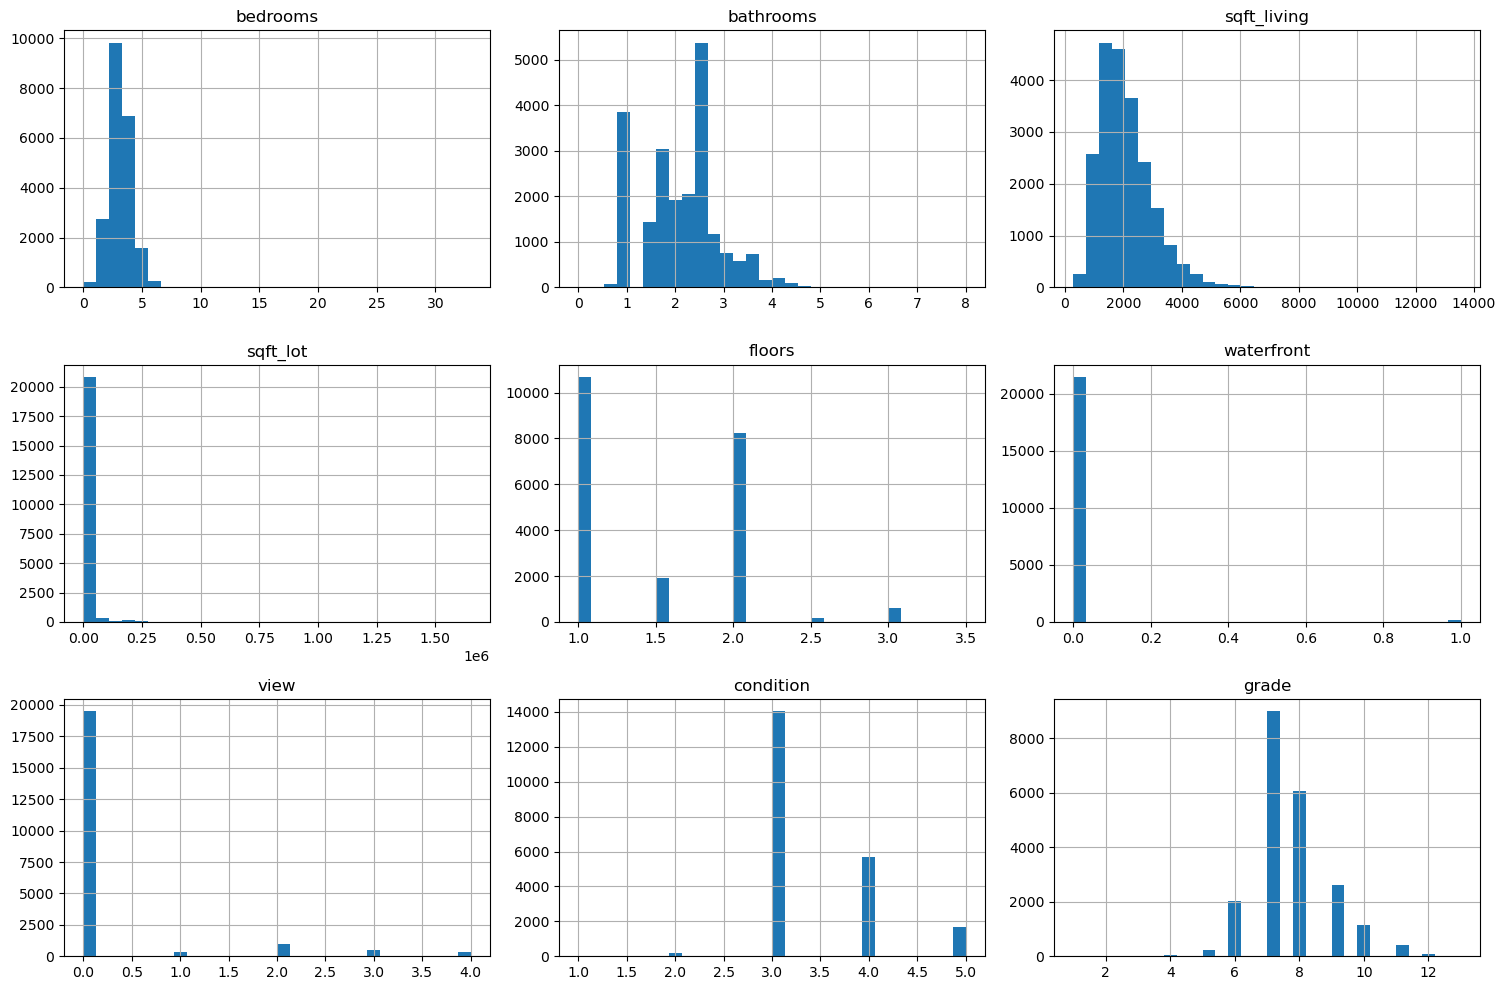

In [40]:
df[['bedrooms','bathrooms','sqft_living','sqft_lot','floors',
    'waterfront','view','condition','grade']].hist(figsize=(15,10),bins=30)
plt.tight_layout()
plt.show()

## 5. Relationship Between Features and Price

Scatter plots are used to visually investigate the relationship between individual numerical features and house price.

The purpose is not to prove that a feature is useful solely from the graph, but to identify possible patterns such as:

* Positive relationships
* Negative relationships
* Linear or nonlinear patterns
* Outliers
* Increasing or decreasing spread
* Features with little obvious relationship to price


In [41]:
#Scatter plots

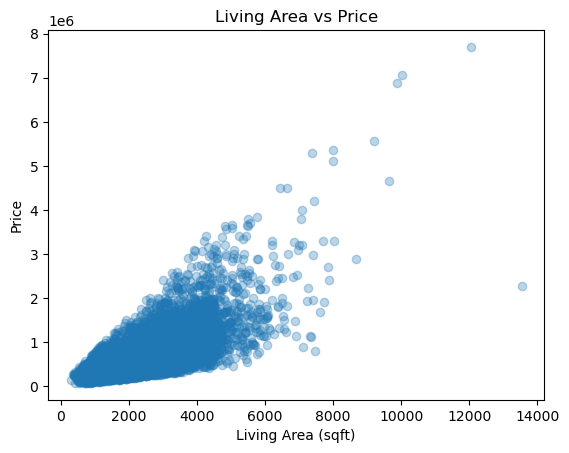

In [48]:
plt.scatter(df['sqft_living'],df['price'],alpha=0.3)
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')
plt.title('Living Area vs Price')
plt.show()

Conclusion :Strong positive relationship

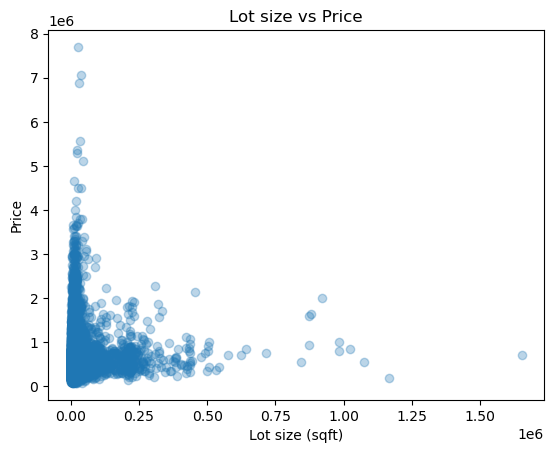

In [44]:
plt.scatter(df['sqft_lot'],df['price'],alpha=0.3)
plt.xlabel('Lot size (sqft)')
plt.ylabel('Price')
plt.title('Lot size vs Price')
plt.show()

Lot size has a very skewed distribution, and its raw scatter plot doesn't show a clear linear relationship with price.

This is exactly where we can later investigate whether a log transformation of sqft_lot makes the relationship easier to see.

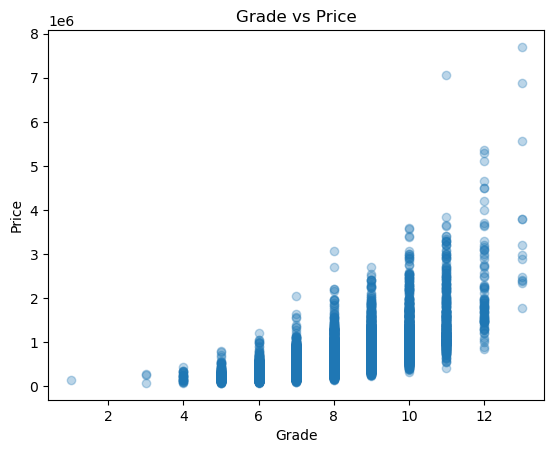

In [49]:
plt.scatter(df['grade'], df['price'], alpha=0.3)
plt.xlabel('Grade')
plt.ylabel('Price')
plt.title('Grade vs Price')
plt.show()

Conclusion : higher grade higher price

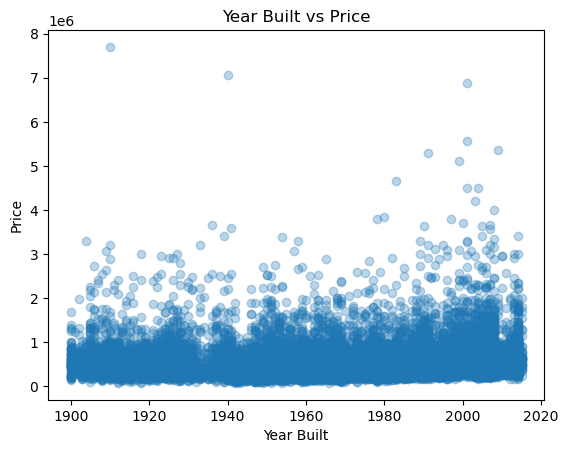

In [50]:
plt.scatter(df['yr_built'], df['price'], alpha=0.3)
plt.xlabel('Year Built')
plt.ylabel('Price')
plt.title('Year Built vs Price')
plt.show()

Conclusion: Positive relationship, but probably not as strong as living area or grade by itself.

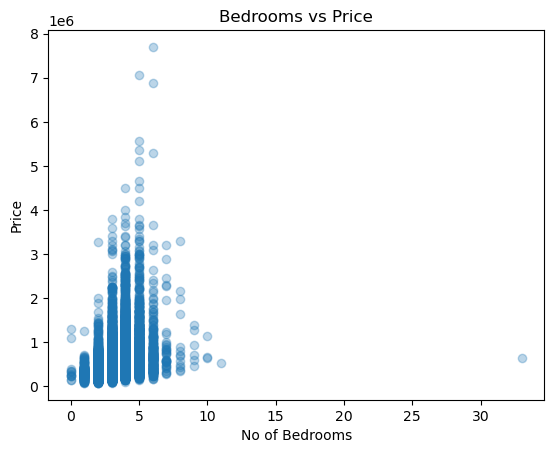

In [51]:
plt.scatter(df['bedrooms'], df['price'], alpha=0.3)
plt.xlabel('No of Bedrooms')
plt.ylabel('Price')
plt.title('Bedrooms vs Price')
plt.show()

bedrooms alone isn't necessarily a strong predictor, because a 3-bedroom house can be 1,000 sqft while another can be 3,000 sqft.

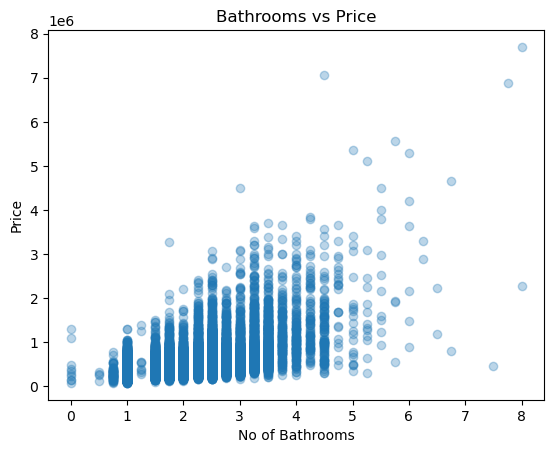

In [52]:
plt.scatter(df['bathrooms'], df['price'], alpha=0.3)
plt.xlabel('No of Bathrooms')
plt.ylabel('Price')
plt.title('Bathrooms vs Price')
plt.show()

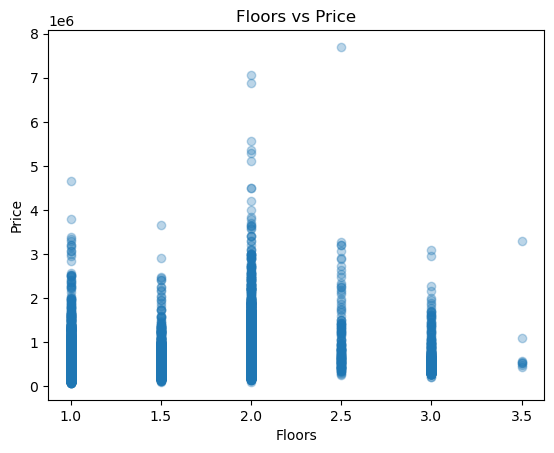

In [53]:
plt.scatter(df['floors'], df['price'], alpha=0.3)
plt.xlabel('Floors')
plt.ylabel('Price')
plt.title('Floors vs Price')
plt.show()

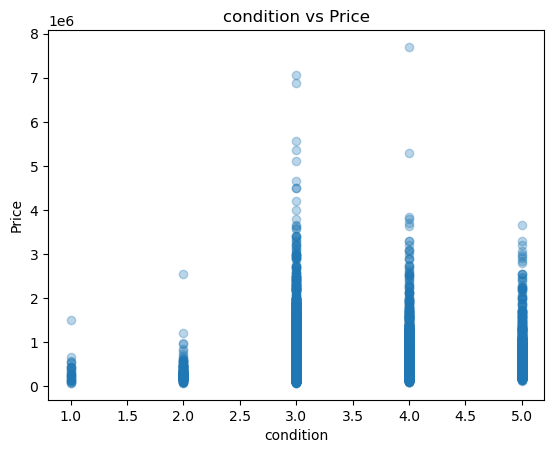

In [54]:
plt.scatter(df['condition'], df['price'], alpha=0.3)
plt.xlabel('condition')
plt.ylabel('Price')
plt.title('condition vs Price')
plt.show()

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           21613 non-null  datetime64[ns]
 1   price          21613 non-null  float64       
 2   bedrooms       21613 non-null  int64         
 3   bathrooms      21613 non-null  float64       
 4   sqft_living    21613 non-null  int64         
 5   sqft_lot       21613 non-null  int64         
 6   floors         21613 non-null  float64       
 7   waterfront     21613 non-null  int64         
 8   view           21613 non-null  int64         
 9   condition      21613 non-null  int64         
 10  grade          21613 non-null  int64         
 11  sqft_above     21613 non-null  int64         
 12  sqft_basement  21613 non-null  int64         
 13  yr_built       21613 non-null  int64         
 14  yr_renovated   21613 non-null  int64         
 15  zipcode        2161

## 6. Baseline Linear Regression Model

To establish a baseline, a Linear Regression model is first trained using only `sqft_living`.

This allows us to measure how well house prices can be predicted using a single important feature before introducing additional variables.

### Features

`X = sqft_living`

### Target

`y = price`


In [90]:
X = df[['sqft_living']]
y= df['price']

In [91]:

X_train,X_test, y_train, y_test, = train_test_split(X,y,train_size =0.8,
                                                    test_size=0.2,random_state=0)

In [92]:
from sklearn.linear_model import LinearRegression
model_LR = LinearRegression()
model_LR.fit(X_train,y_train)
y_pred1 = model_LR.predict(X_test)

In [93]:
print(mean_absolute_error(y_test,y_pred1))

170780.90567679022


### Baseline Result

The model achieved an MAE of approximately **$170,781**.

This means that, on average, the model's predictions differ from the actual house prices by approximately $170,781.

The baseline provides a reference point for evaluating whether adding additional features improves the model.



For example, if the actual house price is:

$500,000

the model might predict something like:

$670,000

or:

$330,000

The absolute error would be about $170,000.

## 7. Multiple Linear Regression

Additional features are gradually added to the model to determine whether they provide useful predictive information beyond `sqft_living`.

Rather than adding all available features at once, different feature combinations are tested and their performance is compared using MAE and R².

This allows us to observe how the model changes as additional information about each property is introduced.


In [95]:
X2 = df[['sqft_living','grade']]
y2 = df['price']

X_train,X_test, y_train, y_test, = train_test_split(X2,y2,train_size =0.8,
                                                    test_size=0.2,random_state=0)

model2 = LinearRegression()
model2.fit(X_train,y_train)
y_pred2 = model2.predict(X_test)

print(mean_absolute_error(y_test,y_pred2))

161048.43825221265


### Model 3 — Adding bathrooms and bedrooms feature

The model is expanded by adding `bathrooms`and `bedrooms`.

These variables provide additional information about the no of bedrooms and bathrooms.

The purpose is to determine whether these features improve predictive performance beyond living area and grade.


In [96]:
X3 = df[['sqft_living','grade','bathrooms','bedrooms']]
y3 = df['price']

X_train,X_test, y_train, y_test, = train_test_split(X3,y3,train_size =0.8,
                                                    test_size=0.2,random_state=0)

model3 = LinearRegression()
model3.fit(X_train,y_train)
y_pred3 = model3.predict(X_test)

print(mean_absolute_error(y_test,y_pred3))

158262.01442526793


### Model 4 — Adding Structural and Quality Features

The model is expanded by adding `yr_built`, `condition`, and `floors`.

These variables provide additional information about the age, physical condition, and structure of the property.

The purpose is to determine whether these features improve predictive performance beyond living area, grade, bedrooms, and bathrooms.


In [97]:
X4 = df[['sqft_living','grade','bathrooms','bedrooms','yr_built','condition','floors']]
y4 = df['price']

X_train,X_test, y_train, y_test, = train_test_split(X4,y4,train_size =0.8,
                                                    test_size=0.2,random_state=0)

model4 = LinearRegression()
model4.fit(X_train,y_train)
y_pred4 = model4.predict(X_test)

print(mean_absolute_error(y_test,y_pred4))

140248.00641488362


In [98]:
from sklearn.metrics import r2_score
print("R²:", r2_score(y_test, y_pred1))
print("R²:", r2_score(y_test, y_pred2))
print("R²:", r2_score(y_test, y_pred3))
print("R²:", r2_score(y_test, y_pred4))

R²: 0.47915775569157537
R²: 0.5371776288416332
R²: 0.5462578456316657
R²: 0.6231428686327463


### Model 5 — Adding Sqft_lot, Sqft_above and year renovated Features

The model is expanded by adding `sqft_lot`, `sqft_above`, and `yr_renovated`.

These variables provide additional information about the renovation year and structure of the property.

The purpose is to determine whether these features improve predictive performance beyond living area, grade, bathrooms, bedrooms, yr_built
, condition and floors


In [107]:
X5 = df[['sqft_living','sqft_lot','sqft_above','grade','yr_renovated','bedrooms','bathrooms','yr_built','condition','floors',]]
y5 = df['price']

X_train,X_test, y_train, y_test, = train_test_split(X5,y5,train_size =0.8,
                                                    test_size=0.2,random_state=0)

model5 = LinearRegression()
model5.fit(X_train,y_train)
y_pred5 = model5.predict(X_test)

print(mean_absolute_error(y_test,y_pred5))
print("R²:", r2_score(y_test, y_pred5))

140091.72992988504
R²: 0.6246180728463535


## 8. Comparing Model Performance

The models are compared using two evaluation metrics:

### Mean Absolute Error (MAE)

MAE measures the average absolute difference between actual and predicted prices.

A lower MAE indicates that the model's predictions are closer to the actual prices.

### R² Score

R² measures the proportion of variation in house prices explained by the model.

A higher R² indicates that the model explains more of the variation in the target variable.

Both metrics are considered because they provide different perspectives on model performance.


In [124]:
results = {
    'Model': ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5'],
    'Features': [
        'sqft_living',
        'sqft_living + grade',
        'sqft_living + grade + bathrooms + bedrooms',
        'sqft_living + grade + bathrooms + bedrooms + yr_built + condition + floors',
        'M4 + sqft_lot + sqft_above + yr_renovated'
    ],
    'MAE': [
        170780.90567679022,
        161048.43825221265,
        158262.01442526793,
        140248.00641488362,
        140091.72992988504
    ],
    'R²': [
        0.47915775569157537,
        0.5371776288416332,
        0.5462578456316657,
        0.6231428686327463,
        0.6246180728463535
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Features,MAE,R²
0,Model 1,sqft_living,170780.905677,0.479158
1,Model 2,sqft_living + grade,161048.438252,0.537178
2,Model 3,sqft_living + grade + bathrooms + bedrooms,158262.014425,0.546258
3,Model 4,sqft_living + grade + bathrooms + bedrooms + y...,140248.006415,0.623143
4,Model 5,M4 + sqft_lot + sqft_above + yr_renovated,140091.729930,0.624618


## 9. Interpreting Regression Coefficients

After training the multiple linear regression model, the learned coefficients are examined.

A coefficient represents the expected change in predicted price associated with a one-unit increase in that feature, **while keeping the other features constant**.

The units of the coefficients differ between features. Therefore, coefficient magnitude alone should not be used to determine which feature is most important.


In [108]:
for feature, coefficient in zip(X5.columns, model5.coef_):
    print(feature, coefficient)

sqft_living 210.11194949417447
sqft_lot -0.22711868073818842
sqft_above -22.268459276108583
grade 129234.5772447874
yr_renovated 21.9505583275535
bedrooms -47941.1597493269
bathrooms 45073.54613391332
yr_built -3843.0277937521887
condition 20867.902126486464
floors 30500.787661627062


In [111]:
print(model5.intercept_)

6680558.564538732


## 10. Correlation Between Predictors

A correlation matrix is used to examine relationships between the independent variables.

Strong correlations between predictors can indicate **multicollinearity**, where multiple features contain overlapping information.

Multicollinearity does not necessarily prevent a model from making predictions, but it can make individual regression coefficients more difficult to interpret.


In [113]:
print(X5.corr())

              sqft_living  sqft_lot  sqft_above     grade  yr_renovated  \
sqft_living      1.000000  0.172826    0.876597  0.762704      0.055363   
sqft_lot         0.172826  1.000000    0.183512  0.113621      0.007644   
sqft_above       0.876597  0.183512    1.000000  0.755923      0.023285   
grade            0.762704  0.113621    0.755923  1.000000      0.014414   
yr_renovated     0.055363  0.007644    0.023285  0.014414      1.000000   
bedrooms         0.576693  0.031713    0.477614  0.356978      0.018850   
bathrooms        0.754665  0.087740    0.685342  0.664983      0.050739   
yr_built         0.318049  0.053080    0.423898  0.446963     -0.224874   
condition       -0.058753 -0.008958   -0.158214 -0.144674     -0.060618   
floors           0.353949 -0.005201    0.523885  0.458183      0.006338   

              bedrooms  bathrooms  yr_built  condition    floors  
sqft_living   0.576693   0.754665  0.318049  -0.058753  0.353949  
sqft_lot      0.031713   0.087740  0.053

## 11. Investigating Multicollinearity Through Feature Selection

`sqft_above` has a strong correlation with `sqft_living`.

To investigate whether it provides additional predictive information, a model without `sqft_above` is compared with the model containing it.

Removing `sqft_above` resulted in a small decrease in performance:

* With `sqft_above`: R² = **0.6246**
* Without `sqft_above`: R² = **0.6242**

This suggests that although `sqft_above` contains information overlapping with `sqft_living`, it still provides a small amount of additional predictive information.


In [114]:
X6 =df[['sqft_living',
         'grade',
         'bathrooms',
         'bedrooms',
         'yr_built',
         'condition',
         'floors',
         'sqft_lot',
         'yr_renovated']]

y6 = df['price']

X_train,X_test, y_train, y_test, = train_test_split(X6,y6,train_size =0.8,
                                                    test_size=0.2,random_state=0)

model6 = LinearRegression()
model6.fit(X_train,y_train)
y_pred6 = model6.predict(X_test)

print(mean_absolute_error(y_test,y_pred6))
print("R²:", r2_score(y_test, y_pred6))

140216.07857257783
R²: 0.624249903168882


sqft_above does provide some additional predictive information, even though it's highly correlated with sqft_living.


## 12. Conclusion

This project demonstrated the basic workflow for building a Linear Regression model for house-price prediction.

The analysis began with exploratory data analysis and visualization, followed by a baseline model using `sqft_living`. Additional features were then introduced incrementally and evaluated using MAE and R².

The best model tested so far achieved:

* **MAE:** $140,091.73
* **R²:** 0.6246

The analysis also demonstrated that relationships observed in scatter plots can differ from individual multiple-regression coefficients because the model estimates each coefficient while controlling for the other predictors.

Correlation analysis revealed strong relationships between several predictors, particularly `sqft_living` and `sqft_above`, highlighting the importance of considering multicollinearity when interpreting regression coefficients.

Further improvements can be made by investigating location features, applying appropriate transformations, performing cross-validation, and analyzing residuals.
